# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2835s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

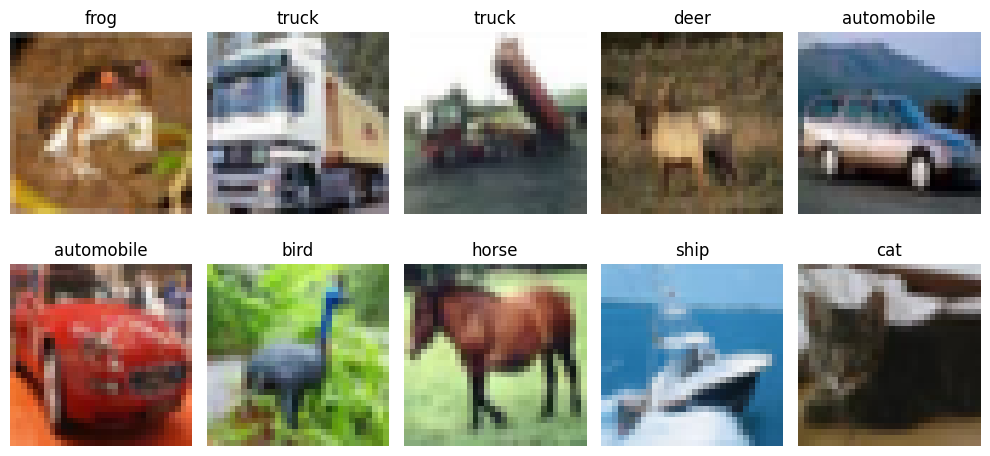

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

Original ANN

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2694 - loss: 2.0029 - val_accuracy: 0.3350 - val_loss: 1.8276
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.3170 - loss: 1.8653 - val_accuracy: 0.3644 - val_loss: 1.7937
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3333 - loss: 1.8229 - val_accuracy: 0.3716 - val_loss: 1.7615
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3525 - loss: 1.7744 - val_accuracy: 0.3734 - val_loss: 1.7317
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3629 - loss: 1.7487 - val_accuracy: 0.4066 - val_loss: 1.6885
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3706 - loss: 1.7294 - val_accuracy: 0.3938 - val_loss: 1.7008
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3809 - loss: 1.7102 - val_accuracy: 0.4132 - val_loss: 1.6838
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3813 - loss: 1.6985 - 

ANN (More Layers)

In [ ]:
ann_more_layers = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_more_layers.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_more_layers_history = ann_more_layers.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.2394 - loss: 2.0395 - val_accuracy: 0.3052 - val_loss: 1.9023
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3076 - loss: 1.8889 - val_accuracy: 0.3278 - val_loss: 1.8501
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.3283 - loss: 1.8382 - val_accuracy: 0.3614 - val_loss: 1.7579
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3420 - loss: 1.8028 - val_accuracy: 0.3650 - val_loss: 1.7602
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3492 - loss: 1.7846 - val_accuracy: 0.3888 - val_loss: 1.7244
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3586 - loss: 1.7577 - val_accuracy: 0.3910 - val_loss: 1.7255
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3667 - loss: 1.7396 - val_accuracy: 0.3876 - val_loss: 1.7237
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3694 - loss: 1.7338 - 

ANN (20 Epochs)

In [ ]:
ann_20_epochs_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_20_epochs_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_20_epochs_history = ann_20_epochs_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2706 - loss: 1.9987 - val_accuracy: 0.3298 - val_loss: 1.8416
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3164 - loss: 1.8731 - val_accuracy: 0.3426 - val_loss: 1.8453
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3384 - loss: 1.8215 - val_accuracy: 0.3674 - val_loss: 1.7690
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3514 - loss: 1.7785 - val_accuracy: 0.4050 - val_loss: 1.7075
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3612 - loss: 1.7614 - val_accuracy: 0.4048 - val_loss: 1.6928
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3726 - loss: 1.7293 - val_accuracy: 0.4126 - val_loss: 1.6831
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3820 - loss: 1.7078 - val_accuracy: 0.4148 - val_loss: 1.6843
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3884 - loss: 1.6849 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

ann_more_layers_test_loss, ann_more_layers_test_acc = ann_more_layers.evaluate(
    x_test_flat, y_test
)
print("ANN More Layers Test Accuracy:", ann_more_layers_test_acc)

ann_20_epochs_test_loss, ann_20_epochs_test_acc = ann_20_epochs_model.evaluate(
    x_test_flat, y_test
)
print("ANN 20 Epochs Test Accuracy:", ann_20_epochs_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4022 - loss: 1.6597
ANN Test Accuracy: 0.40220001339912415
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4280 - loss: 1.6393
ANN More Layers Test Accuracy: 0.42800000309944153
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4510 - loss: 1.5620
ANN 20 Epochs Test Accuracy: 0.45100000500679016


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

Original CNN

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 133ms/step - accuracy: 0.4640 - loss: 1.4983 - val_accuracy: 0.5454 - val_loss: 1.3038
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 132ms/step - accuracy: 0.6130 - loss: 1.1061 - val_accuracy: 0.6294 - val_loss: 1.0608
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 133ms/step - accuracy: 0.6759 - loss: 0.9318 - val_accuracy: 0.6506 - val_loss: 1.0318
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7151 - loss: 0.8171 - val_accuracy: 0.6532 - val_loss: 0.9919
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 131ms/step - accuracy: 0.7483 - loss: 0.7238 - val_accuracy: 0.7046 - val_loss: 0.8692
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 133ms/step - accuracy: 0.7737 - loss: 0.6469 - val_accuracy: 0.6714 - val_loss: 1.0346
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 134ms/step - accuracy: 0.7963 - loss: 0.5747 - val_accuracy: 0.7222 - val_loss: 0.8817
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 131ms/step - accuracy: 0.8133 - loss

CNN (More Filters)

In [ ]:
cnn_more_filters = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_more_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_more_filters_history = cnn_more_filters.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 347s 487ms/step - accuracy: 0.4803 - loss: 1.4659 - val_accuracy: 0.4908 - val_loss: 1.4912
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 386s 493ms/step - accuracy: 0.6284 - loss: 1.0658 - val_accuracy: 0.6132 - val_loss: 1.0940
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 374s 483ms/step - accuracy: 0.7077 - loss: 0.8520 - val_accuracy: 0.7076 - val_loss: 0.8574
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 336s 478ms/step - accuracy: 0.7613 - loss: 0.6946 - val_accuracy: 0.7100 - val_loss: 0.8433
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 335s 476ms/step - accuracy: 0.8028 - loss: 0.5745 - val_accuracy: 0.7142 - val_loss: 0.8600
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 337s 478ms/step - accuracy: 0.8363 - loss: 0.4768 - val_accuracy: 0.6532 - val_loss: 1.1996
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 335s 476ms/step - accuracy: 0.8679 - loss: 0.3839 - val_accuracy: 0.6262 - val_loss: 1.6668
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 386s 482ms/step - accuracy: 0.8895 -

CNN (20 Epochs)

In [ ]:
cnn_20_epochs_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20_epochs_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20_epochs_history = cnn_20_epochs_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4740 - loss: 1.4782 - val_accuracy: 0.5654 - val_loss: 1.2355
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6093 - loss: 1.1185 - val_accuracy: 0.6180 - val_loss: 1.1138
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.6668 - loss: 0.9552 - val_accuracy: 0.5552 - val_loss: 1.3400
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.7078 - loss: 0.8360 - val_accuracy: 0.6922 - val_loss: 0.9396
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7416 - loss: 0.7462 - val_accuracy: 0.7182 - val_loss: 0.8414
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7661 - loss: 0.6695 - val_accuracy: 0.7268 - val_loss: 0.8319
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7896 - loss: 0.5983 - val_accuracy: 0.7302 - val_loss: 0.8505
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.8129 - loss: 

CNN + EarlyStopping

In [ ]:
cnn_earlystop_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_earlystop_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_earlystop_history = cnn_earlystop_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4676 - loss: 1.4874 - val_accuracy: 0.4870 - val_loss: 1.4568
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.6062 - loss: 1.1330 - val_accuracy: 0.6630 - val_loss: 0.9729
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 127ms/step - accuracy: 0.6695 - loss: 0.9456 - val_accuracy: 0.6192 - val_loss: 1.0935
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.7101 - loss: 0.8303 - val_accuracy: 0.6120 - val_loss: 1.1284
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 127ms/step - accuracy: 0.7470 - loss: 0.7263 - val_accuracy: 0.6440 - val_loss: 1.0735


In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

cnn_more_filters_test_loss, cnn_more_filters_test_acc = cnn_more_filters.evaluate(
    x_test_norm, y_test
)

print("CNN More Filters Test Accuracy:", cnn_more_filters_test_acc)

cnn_20_epochs_test_loss, cnn_20_epochs_test_acc = cnn_20_epochs_model.evaluate(
    x_test_norm, y_test
)

print("CNN 20 Epochs Test Accuracy:", cnn_20_epochs_test_acc)

cnn_earlystop_test_loss, cnn_earlystop_test_acc = cnn_earlystop_model.evaluate(
    x_test_norm, y_test
)

print("CNN + EarlyStopping Test Accuracy:", cnn_earlystop_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7286 - loss: 0.8737
CNN Test Accuracy: 0.728600025177002
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7387 - loss: 1.0925
CNN More Filters Test Accuracy: 0.7386999726295471
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7293 - loss: 1.2764
CNN 20 Epochs Test Accuracy: 0.7293000221252441
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6512 - loss: 1.0053
CNN + EarlyStopping Test Accuracy: 0.651199996471405


## 📈 Compare Learning Curves

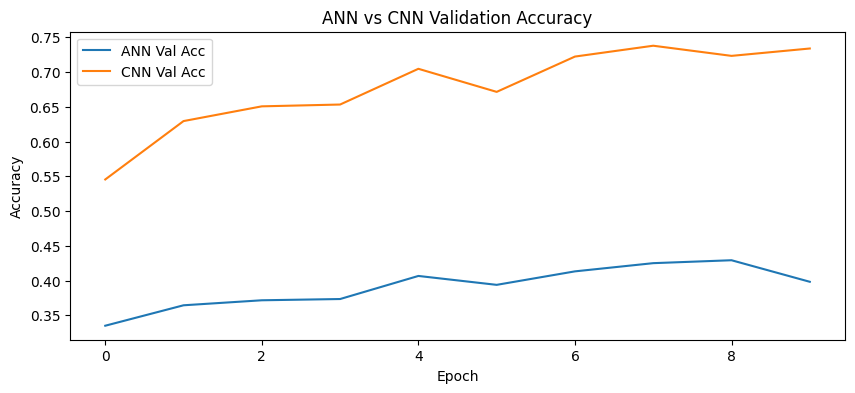

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - accuracy: 0.3538 - loss: 1.7635 - val_accuracy: 0.4644 - val_loss: 1.4505
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.4549 - loss: 1.5151 - val_accuracy: 0.5354 - val_loss: 1.3099
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.4950 - loss: 1.4121 - val_accuracy: 0.5490 - val_loss: 1.2275


In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4617 - loss: 1.4609
Augmented CNN Accuracy: 0.4616999924182892


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4022
1,CNN,0.7286


In [ ]:
# Final Comparison Table

comparison = pd.DataFrame({
    "Model": [
        "Original ANN",
        "ANN More Layers",
        "ANN 20 Epochs",
        "Original CNN",
        "CNN More Filters",
        "CNN 20 Epochs",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_more_layers_test_acc,
        ann_20_epochs_test_acc,
        cnn_test_acc,
        cnn_more_filters_test_acc,
        cnn_20_epochs_test_acc,
        cnn_earlystop_test_acc,
        aug_test_acc
    ]
})

comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Test Accuracy
4,CNN More Filters,0.7387
5,CNN 20 Epochs,0.7293
3,Original CNN,0.7286
6,CNN + EarlyStopping,0.6512
7,CNN + Data Augmentation,0.4617
2,ANN 20 Epochs,0.4510
1,ANN More Layers,0.4280
0,Original ANN,0.4022


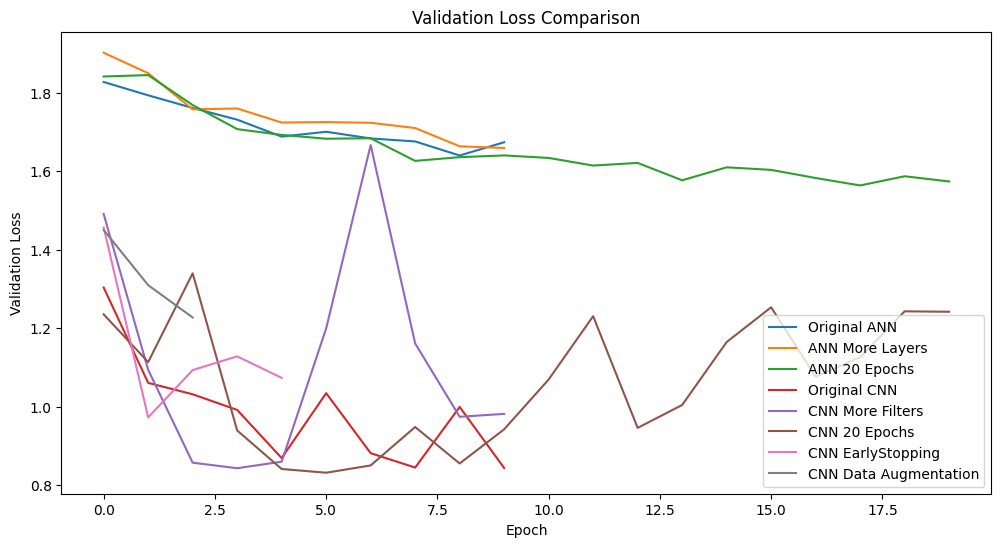

In [ ]:
# Loss Curves Comparison

plt.figure(figsize=(12,6))

plt.plot(ann_history.history['val_loss'], label="Original ANN")
plt.plot(ann_more_layers_history.history['val_loss'], label="ANN More Layers")
plt.plot(ann_20_epochs_history.history['val_loss'], label="ANN 20 Epochs")

plt.plot(cnn_history.history['val_loss'], label="Original CNN")
plt.plot(cnn_more_filters_history.history['val_loss'], label="CNN More Filters")
plt.plot(cnn_20_epochs_history.history['val_loss'], label="CNN 20 Epochs")
plt.plot(cnn_earlystop_history.history['val_loss'], label="CNN EarlyStopping")
plt.plot(aug_history.history['val_loss'], label="CNN Data Augmentation")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

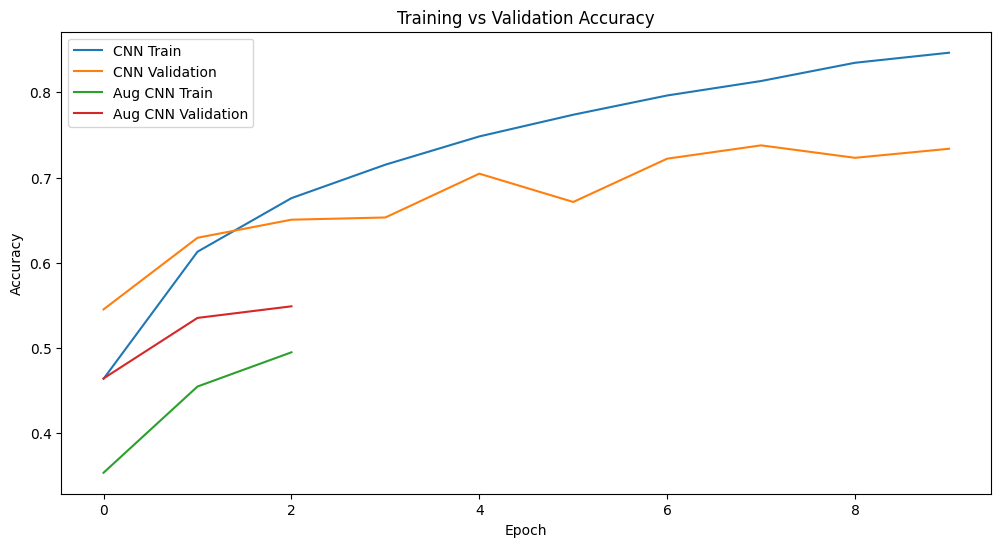

In [ ]:
# Generalization Analysis (Train vs Validation Accuracy)

plt.figure(figsize=(12,6))

plt.plot(cnn_history.history['accuracy'], label="CNN Train")
plt.plot(cnn_history.history['val_accuracy'], label="CNN Validation")

plt.plot(aug_history.history['accuracy'], label="Aug CNN Train")
plt.plot(aug_history.history['val_accuracy'], label="Aug CNN Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
# Training Strategy Comparison Summary

strategy_comparison = pd.DataFrame({
    "Strategy": [
        "Baseline Architecture",
        "Increase Network Depth",
        "Increase Epochs",
        "Increase Filters",
        "Early Stopping",
        "Data Augmentation"
    ],
    "Purpose": [
        "Establish baseline performance",
        "Learn more complex features",
        "Allow longer training",
        "Improve feature extraction",
        "Reduce overfitting",
        "Improve generalization"
    ]
})

strategy_comparison

,Strategy,Purpose
0,Baseline Architecture,Establish baseline performance
1,Increase Network Depth,Learn more complex features
2,Increase Epochs,Allow longer training
3,Increase Filters,Improve feature extraction
4,Early Stopping,Reduce overfitting
5,Data Augmentation,Improve generalization


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# 📝 Experiment Summary

In this project, we built and compared multiple Artificial Neural Network (ANN) and Convolutional Neural Network (CNN) architectures on the CIFAR-10 image classification dataset. The objective was to analyze how different architectures and training strategies affect model performance.

### Experiments Performed
- Original ANN
- ANN with More Layers
- ANN trained for 20 Epochs
- Original CNN
- CNN with More Filters
- CNN trained for 20 Epochs
- CNN with Early Stopping
- CNN with Data Augmentation

### Key Observations
- The original ANN achieved the lowest accuracy because it treats images as one-dimensional vectors and cannot capture spatial information.
- Increasing the number of ANN layers and training for more epochs resulted in a moderate improvement in performance.
- The original CNN significantly outperformed all ANN models by learning spatial features using convolutional layers.
- Increasing the number of filters slightly improved CNN accuracy but also increased training time and model complexity.
- Training the CNN for 20 epochs provided only a small improvement and showed signs of overfitting after several epochs.
- Early Stopping prevented unnecessary training and helped reduce overfitting, although its effectiveness depended on the chosen patience value.
- Data Augmentation improved the model's ability to generalize by exposing it to transformed images during training.

### Overall Conclusion
The experiments demonstrate that CNNs are much better suited for image classification than ANNs because they preserve and learn spatial features. While increasing model depth and training duration can improve performance, techniques such as Batch Normalization, Dropout, Early Stopping, and Data Augmentation are important for achieving better generalization and preventing overfitting. Overall, CNN-based models produced the best performance on the CIFAR-10 dataset.